In [1]:
from typing import Callable
from itertools import tee
from functools import partial
from time import perf_counter

import numpy as np

import jax

from jax import numpy as jnp
from jax import Array

import equinox as eqx

from atr.states import TransverseFieldSpectrum
from atr.operator import operator_expect_and_variance, operator_expect, ZZ, X
from atr.operator.spin import to_dense
from atr.transport import inverse_power_update
from atr.graph import Cube
from atr.models import ResidualRBM
from atr.sampler import SpinSampler
from atr.models import model_params, param_count
from atr.utils import default_complex_dtype, vmap
from atr.linalg import SoftSpectralSolver

import matplotlib.pyplot as plt

In [2]:
key = jax.random.PRNGKey(42)

This notebook runs through an example of computing an excited state using adiabatic transport with neural quantum states (NQS).

We work on a circle with $L=10$ sites.

In [3]:
graph = Cube((10,), pbc=True)

In [4]:
sampler = SpinSampler(graph.shape, n_samples=64, n_chains=4)

We initialize the state as $\ln \psi _{\theta(\lambda)}(\mathbb{x}) = a \ln \psi _0 (\mathbb{x}) + b \ln \phi _{\theta (\lambda)} (\mathbb{x})$. The NQS component $\phi _{\theta (\lambda)} (\mathbb{x})$ is chosen as a custom architecture we call a *residual* RBM but really any sufficiently expressive architecture should work. The initial state $\psi _0 (\mathbb{x})$ is chosen as the first excited state of the transverse field Ising model at $\lambda=0$, which is exactly known.

In [5]:
class InitialCondition(eqx.Module):

    init_cond: Callable
    model: eqx.Module
    coeffs: Array

    def __init__(self, init_cond, model):
        self.init_cond = init_cond
        self.model = model
        self.coeffs = jnp.array([1.0, 1.0])

    def __call__(self, x: Array) -> Array:
        a, b = self.coeffs
        return a * self.init_cond(x) + b * self.model(x)
    
spectrum = TransverseFieldSpectrum(graph, corrected=True)
ctype = default_complex_dtype()

def init_logpsi(x):
    psi = spectrum.excited_state(x)[0]
    return jnp.log(psi.astype(ctype) + 1e-4)

key, init_key = jax.random.split(key, 2)
nqs = ResidualRBM(graph.shape, n_channels=4, n_blocks=2, kernel_size=5, key=init_key)

logpsi = InitialCondition(init_logpsi, nqs)

In [6]:
print(f"Number of parameters: {param_count(logpsi)}")

Number of parameters: 1138


We consider a system of $N=10$ spins on a one-dimensional lattice with periodic boundary conditions with the Hamiltonian
$$
H = - \lambda \sum _{i=1} ^{N} \sigma _i ^z \sigma _{i+1} ^z - \sum _{i=1} ^{N} \sigma _i ^x
$$
where $\sigma _i ^{x,y,z}$ are the Pauli matrices acting on site $i$ and $\lambda$ is the Ising coupling we transport along. Setting $H_0 = -\sum _i \sigma _i ^x$ and $V = -\sum _i \sigma _i ^z \sigma _{i+1} ^z$, the Hamiltonian can reads $H_\lambda = H_0 + \lambda V$.

In [7]:
H0, V = -X(graph), -ZZ(graph)

The ground state of this model is well-known to undergo a quantum phase transition at $\lambda=1$. Therefore, we set up the $\lambda$ grid to go from $\lambda=0$ to $\lambda=1$ in $20$ steps with denser spacing near the critical point.

In [8]:
li, lf = 0.0, 1.0
npts = 20
alpha = 3.0

idx = jnp.linspace(0, 1, npts)
lambda_grid = lf * (1 - jnp.exp(-alpha * idx)) / (1 - jnp.exp(-alpha))

print("Lambda grid:")
print(lambda_grid)

lambda_grid = lambda_grid.tolist()

Lambda grid:
[0.         0.15371327 0.28497508 0.39706483 0.49278268 0.57452
 0.64431864 0.7039225  0.75482064 0.7982845  0.8354001  0.8670945
 0.8941597  0.9172717  0.9370079  0.9538615  0.9682534  0.98054326
 0.9910381  1.        ]


## ED reference data

The $L=10$ system is small enough to be solved exactly using exact diagonalization (ED). We brute force the full Hamiltonian matrix and use `jnp.linalg.eigvalsh` to compute the full eigenspectrum at each $\lambda$ value. This gives us a reference to compare our NQS results against.

In [9]:
# @eqx.filter_jit
@partial(vmap, chunk_size=20)
def ed_energies(l):
    Hmat = to_dense(H0 + l * V)
    energies = jnp.linalg.eigvalsh(Hmat)
    return energies[:2]

In [10]:
ed_grid = jnp.linspace(li, lf, 50)
ed_energy_vals = ed_energies(ed_grid)

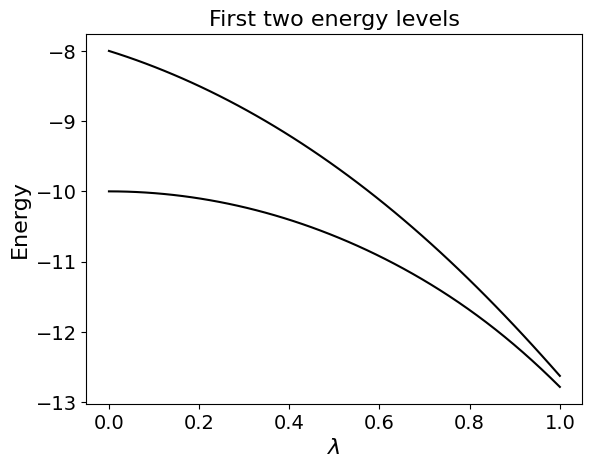

In [11]:
plt.plot(ed_grid, ed_energy_vals, label="ED", color="black")
plt.xlabel(r"$\lambda$", fontsize=16)
plt.ylabel("Energy", fontsize=16)
plt.title("First two energy levels", fontsize=16)
plt.xticks(fontsize=14)
_ = plt.yticks(fontsize=14)

## The adiabatic transport

In [12]:
@eqx.filter_jit
def estimate_energy(logpsi, H, key):
    samples = sampler(logpsi, key).reshape(-1, *graph.shape)
    return operator_expect_and_variance(H, logpsi, samples, chunk_size=64)

In [13]:
@eqx.filter_jit
def update_energy(logpsi, energy, potential, step_size, key):
    samples = sampler(logpsi, key).reshape(-1, *graph.shape)
    V_exp = operator_expect(potential, logpsi, samples,  chunk_size=64)
    return energy + step_size * V_exp

In [14]:
def cosine_schedule(max_val, min_val, n_steps, start=0.0, end=1.0):

    assert 0.0 <= start < end <= 1.0, "Start and end must be in the range [0, 1] and start < end."
    start_step, end_step = int(start * n_steps), int(end * n_steps)

    def schedule(step):
        scaled_step = (step - start_step) / (end_step - start_step)
        scaled_step = jnp.clip(scaled_step, 0.0, 1.0)
        return min_val + (max_val - min_val) * jnp.cos(jnp.pi * scaled_step / 2) ** 2

    return schedule

The adiabatic transport is performed using a modified version of the *shift-and-invert* or the *inverse power iteration* (IPI) algorithm. This allows us to efficiently compute the ground state energy and wavefunction at each point in the $\lambda$ parameter space. In the hilbert space, the algorithm iterates the following transformation:
$$
\ket{\Psi '} \propto \left( H - \omega \right)^{-1} \ket{\Psi}
$$
where $\omega$ is the target energy. This transformation amplifies the component of the wavefunction corresponding to the eigenvalue closest to $\omega$, allowing us to converge to the desired excited state.

For the NQS implementation, we it can be shown that the parameter update $\delta \theta$ reflecting one IPI step is given by $\mathbf{G} \; \delta \theta = - f$ where
$$
\mathbf{G} _{\mu \nu} = 2 \text{Re} \; \bra{\partial _\mu \Psi _\theta} \left( H_\lambda - \omega_\lambda \right) \ket{\partial _\nu \Psi _\theta}
$$
$$
f _\mu = 2 \text{Re} \; \bra{\partial _\mu \Psi _\theta} H_\lambda \ket{\Psi _\theta}
$$

The function `inverse_power_update` calculates precisely this $\delta \theta$ update. New parameters are then given by $\theta \leftarrow \theta + \eta \; \delta \theta$ with some *dampening* factor $\eta$. Heuristically, we also anneal $\eta$ using a `cosine_schedule` but that might not be necessary in all cases.

In [15]:
linear_solver = SoftSpectralSolver(rcond=1e-5, acond=1e-7)
dampening_schedule = cosine_schedule(0.2, 1e-3, 100, start=0.0, end=0.9)

@eqx.filter_jit
def inverse_power_iter(logpsi, hamiltonian, target_energy, i, key):

    samples = sampler(logpsi, key).reshape(-1, *graph.shape)

    E, E_var = operator_expect_and_variance(hamiltonian, logpsi, samples, chunk_size=64)
    d_logpsi = inverse_power_update(logpsi, samples, hamiltonian, target_energy, solver=linear_solver, chunk_size=64)
    d_logpsi = jax.tree.map(lambda x: dampening_schedule(i) * x, d_logpsi)
    logpsi_ = eqx.apply_updates(logpsi, d_logpsi)

    return logpsi_, (E, E_var)

We wrap the whole thing in an external for loop controlling when to end the IPI process. We use a maximum number of iterations and a convergence threshold on the energy change between iterations as stopping criteria. This is a heuristic approach and can probably be improved.

In [16]:
max_ipi = 100
var_cutoff = 1e-4
var_lookback = 10

def optimize_state(logpsi, hamiltonian, target_energy, key):

    energies, variances = [], []
    n_spins = graph.num_nodes

    i = jnp.array(0)
    control = 1000.0

    while (control > var_cutoff and i < max_ipi) or i < var_lookback:

        i += 1
        i_ = jnp.array(i, dtype=jnp.int32)

        key = jax.random.fold_in(key, i)
        logpsi, (energy, var) = inverse_power_iter(logpsi, hamiltonian, target_energy, i_, key)

        energies.append(energy.item())
        variances.append(var.item())
        control = np.std(variances[-var_lookback :]) / n_spins

    return logpsi

We initialize the NQS ansatz for the first $\lambda >0 $ point in `lambda_grid`.

In [17]:
key, key1, key2 = jax.random.split(key, 3)

In [18]:
step_size = lambda_grid[1] - lambda_grid[0]

samples = sampler(logpsi.init_cond, key).reshape(-1, *graph.shape)
E0 = operator_expect(H0, logpsi.init_cond, samples, chunk_size=64)
target_energy = update_energy(logpsi.init_cond, E0, V, step_size, key1)

print(f"Initial energy: {E0:.10e}")
print(f" Target energy: {target_energy:.10e}")

H = H0 + step_size * V
logpsi = optimize_state(logpsi, H, target_energy, key2)
_ = lambda_grid.pop(0)

Initial energy: -7.9999284744e+00
 Target energy: -8.2833375931e+00


In [19]:
E, E_var = estimate_energy(logpsi, H, key2)

Pretty-print the converged initial parameters:

In [20]:
print(f"Lambda value: {lambda_grid[0]:.4f}")
print(f"Eigenstate energy: {E:.10e}")
print(f"Energy variance  : {E_var:.10e}")

Lambda value: 0.1537
Eigenstate energy: -8.3654384613e+00
Energy variance  : 8.4647057520e-05


Finally, perform the adiabatic transport along the $\lambda$ grid, storing the energy and the wavefunction at each point. This might take a second, depending on your hardware.

In [21]:
def pairs(iterable):
    a, b = tee(iterable)
    next(b, None)
    return zip(a, b)

In [22]:
y = [model_params(logpsi)]
energies = [E.item()]
energy_vars = [E_var.item()]

clock = perf_counter()

for i, (li, lf) in enumerate(pairs(lambda_grid)):

    key_ = jax.random.fold_in(key, i)
    key1, key2, key3 = jax.random.split(key_, 3)

    step_size = lf - li
    H = H0 + lf * V

    target_energy = update_energy(logpsi, E, V, step_size, key1)
    logpsi = optimize_state(logpsi, H, target_energy, key2)
    E, E_var = estimate_energy(logpsi, H, key3)

    y.append(model_params(logpsi))
    E, E_var = E.item(), E_var.item()
    energies.append(E)
    energy_vars.append(E_var)

    time_per_step = (perf_counter() - clock) / (i + 1)

    print(
        f"Iteration {i+1:4} | Lambda: {lf:.4e} | Step size {step_size:.4e} | Energy {E:.4e} | Energy var. {E_var:.4e} | Time per step: {time_per_step:.4e}"
    )

Iteration    1 | Lambda: 2.8498e-01 | Step size 1.3126e-01 | Energy -8.7740e+00 | Energy var. 1.2513e-04 | Time per step: 1.0895e+02
Iteration    2 | Lambda: 3.9706e-01 | Step size 1.1209e-01 | Energy -9.1902e+00 | Energy var. 6.5806e-04 | Time per step: 1.1716e+02
Iteration    3 | Lambda: 4.9278e-01 | Step size 9.5718e-02 | Energy -9.6017e+00 | Energy var. 8.3851e-04 | Time per step: 1.1452e+02
Iteration    4 | Lambda: 5.7452e-01 | Step size 8.1737e-02 | Energy -9.9919e+00 | Energy var. 7.0362e-04 | Time per step: 1.1068e+02
Iteration    5 | Lambda: 6.4432e-01 | Step size 6.9799e-02 | Energy -1.0356e+01 | Energy var. 8.1846e-04 | Time per step: 1.1271e+02
Iteration    6 | Lambda: 7.0392e-01 | Step size 5.9604e-02 | Energy -1.0687e+01 | Energy var. 1.1362e-03 | Time per step: 1.1229e+02
Iteration    7 | Lambda: 7.5482e-01 | Step size 5.0898e-02 | Energy -1.0985e+01 | Energy var. 1.0549e-03 | Time per step: 1.0959e+02
Iteration    8 | Lambda: 7.9828e-01 | Step size 4.3464e-02 | Energy -

Plot the energy along the transport path, comparing against the ED reference data.

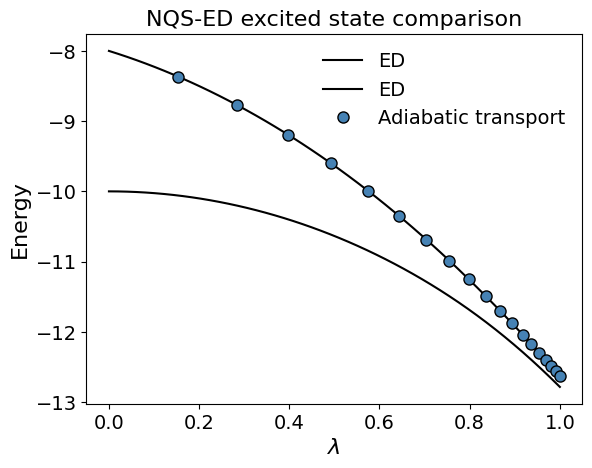

In [23]:
fig, ax = plt.subplots()

ax.plot(ed_grid, ed_energy_vals, label="ED", color="black")
ax.plot(lambda_grid, energies, marker='o', ls='none', color='steelblue', ms=8, markeredgecolor='black', label="Adiabatic transport")

ax.set_xlabel(r"$\lambda$", fontsize=16)
ax.set_ylabel("Energy", fontsize=16)
ax.set_title("NQS-ED excited state comparison", fontsize=16)
ax.legend(fontsize=14, frameon=False)
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)

Plot the energy variance along the transport path. A low variance indicates that the wavefunction is close to an eigenstate of the Hamiltonian.

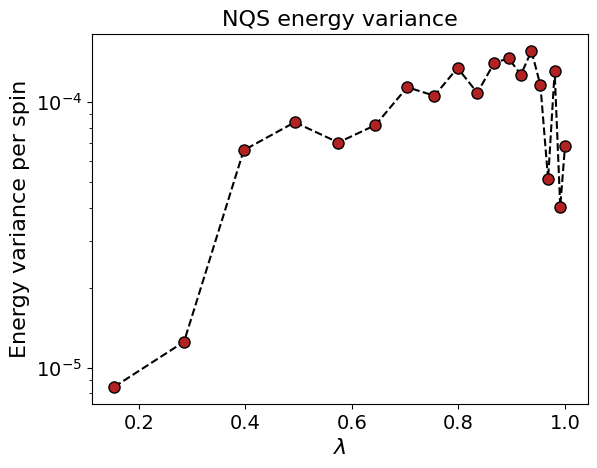

In [24]:
fig, ax = plt.subplots()

ax.semilogy(
    lambda_grid,
    np.array(energy_vars) / 10,
    marker="o",
    ls="--",
    color="black",
    ms=8,
    markerfacecolor="firebrick",
    markeredgecolor="black",
    label="Adiabatic transport",
)

ax.set_xlabel(r"$\lambda$", fontsize=16)
ax.set_ylabel("Energy variance per spin", fontsize=16)
ax.set_title("NQS energy variance", fontsize=16)
ax.tick_params(axis="x", labelsize=14)
ax.tick_params(axis="y", labelsize=14)